# 040 — Signal evaluation: deterministic architectures

Scores the two hidden-detail signals available to a deterministic model — **raw delta** `|real_IR - pred|` and **structural delta** `1 - local SSIM structure` (`scripts.delta_analysis`) — against real hand-drawn ground-truth masks, for all 6 deterministic architectures (`unet`, `resunet`, `attention_unet`, `efficientnet_unet`, `unet_v2`, `unet_restormer`). Companion notebooks, all restricted to the same ground-truth image set:

| notebook | scores | signals |
|---|---|---|
| `040_signal_evaluation.ipynb` (this one) | the 6 deterministic architectures | raw delta, structural delta |
| `041_signal_evaluation_nll.ipynb` | the 8 NLL architecture/loss combinations | + `\|z\|` (raw/sigma), structural z-score, sigma calibration |
| `042_signal_evolution.ipynb` | every model from both, together | per-model comparison of which refinement (structural, sigma-normalization) actually helps |

Real-mask-only and deterministic-only, matching the 03x split — an earlier session's exploratory notebook mixed both families together and scored against a data-derived pseudo-mask before real masks existed. Non-ground-truth `data/test/` images (`bridge`, `case`, `face`, `green`, `modern`, `modern2`, `total`) are deliberately out of scope here — they belong to the perceptual/qualitative 05x series, since there is no mask to score them against.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check. `scripts.delta_analysis` builds the structural delta (same 11×11/σ=1.5 Gaussian window as `tf.image.ssim`); `scripts.detection` scores a signal against a mask (AUROC/average precision); `scripts.stroke_stats` is the reference-free corroborating axis.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import compute_local_stats, compute_ssim_components
from scripts.detection import rank_signals
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.visualization import plot_gt_signal_gallery

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Ground-truth images

Discovered generically from `data/test/annotations/*_Map.png` — any pair with a matching mask is picked up automatically, so adding a new ground-truth image (a new `<stem>_Map.png` plus its `rgb`/`ir` pair) extends every table below without touching this notebook. Currently `GT01`, `GT02`, `GT03`.


In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

mask_paths = (
    sorted(ANNOTATIONS_DIR.glob("*_Map.png")) if ANNOTATIONS_DIR.exists() else []
)
eval_pairs = []
for mask_path in mask_paths:
    stem = mask_path.name.removesuffix("_Map.png")
    rgb_path, ir_path = TEST_RGB_DIR / f"{stem}.jpg", TEST_IR_DIR / f"{stem}.jpg"
    if rgb_path.exists() and ir_path.exists():
        eval_pairs.append((rgb_path, ir_path))
    else:
        print(f"[skip] {stem}: mask found but rgb/ir pair missing")

print(f"Ground-truth images: {len(eval_pairs)} | {[p.stem for p, _ in eval_pairs]}")

if len(eval_pairs) < 2:
    raise RuntimeError(
        "Need at least 2 ground-truth images for the ranking's std and the "
        "per-image breakdown to mean anything. Add masks to "
        "data/test/annotations/."
    )

Ground-truth images: 3 | ['GT01', 'GT02', 'GT03']


## 2. Load the deterministic architectures

All 6 from `models/deterministic/<arch>/best_model.keras`. Missing checkpoints are skipped with a message, not an error.


In [4]:
ARCHS = [
    "unet",
    "resunet",
    "attention_unet",
    "efficientnet_unet",
    "efficientnet_unet_ft",
    "unet_v2",
    "unet_restormer",
    "unet_dilated",
    "unet_v2_dilated",
]
MODEL_DIR = settings.MODELS_DIR / "deterministic"

models: dict = {}
for arch in ARCHS:
    try:
        models[arch] = load_model(arch, model_dir=MODEL_DIR)
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")

print(f"Loaded: {list(models)}")
if not models:
    raise RuntimeError(
        "No deterministic checkpoints found under models/deterministic/."
    )

2026-08-26 12:42:32.191600: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 12:42:32.191624: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 12:42:32.191631: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 12:42:32.191644: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 12:42:32.191653: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded: ['unet', 'resunet', 'attention_unet', 'efficientnet_unet', 'efficientnet_unet_ft']


## 3. Build signals

For each ground-truth image and each loaded model: predict, then build the two candidate signals. **raw delta** is the direct pixel-wise error; **structural delta** isolates the SSIM structure term, which the earlier `033_bis`/`034` runs found carries almost all of the detection signal (structural AUROC ~0.65-0.81 vs. raw delta at ~chance) — both are kept here so this notebook's own numbers reproduce that finding rather than assume it.


In [5]:
def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load an ``(rgb, ir)`` pair as float arrays in ``[0, 1]``."""
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges


def load_mask(stem: str) -> np.ndarray:
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def structural_delta_map(ir: np.ndarray, pred: np.ndarray) -> np.ndarray:
    """``1 - local SSIM structure`` between the real and predicted IR."""
    stats = compute_local_stats(ir, pred)
    return 1.0 - compute_ssim_components(stats).structure


def signals_for(rgb: np.ndarray, ir: np.ndarray) -> dict[str, np.ndarray]:
    """Build ``{"<arch> [raw delta]": map, "<arch> [structural delta]": map, ...}``."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    batch = padded[tf.newaxis, ...]

    signals = {}
    for name, model in models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, 0]
        signals[f"{name} [raw delta]"] = np.abs(ir - pred)
        signals[f"{name} [structural delta]"] = structural_delta_map(ir, pred)
    return signals

## 3b. Visual comparison — RGB / real IR / ground-truth mask vs. generated signals

Qualitative check before the numeric ranking below: for each ground-truth image, does the underdrawing marked in the mask actually show up in each model's signal, or only in the AUROC number? `scripts.visualization.plot_gt_signal_gallery` shows the RGB/real-IR/mask context panels on their natural scale, then every signal panel independently percentile-clipped (the signals below are not on a shared scale).

2026-08-26 12:42:36.188943: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


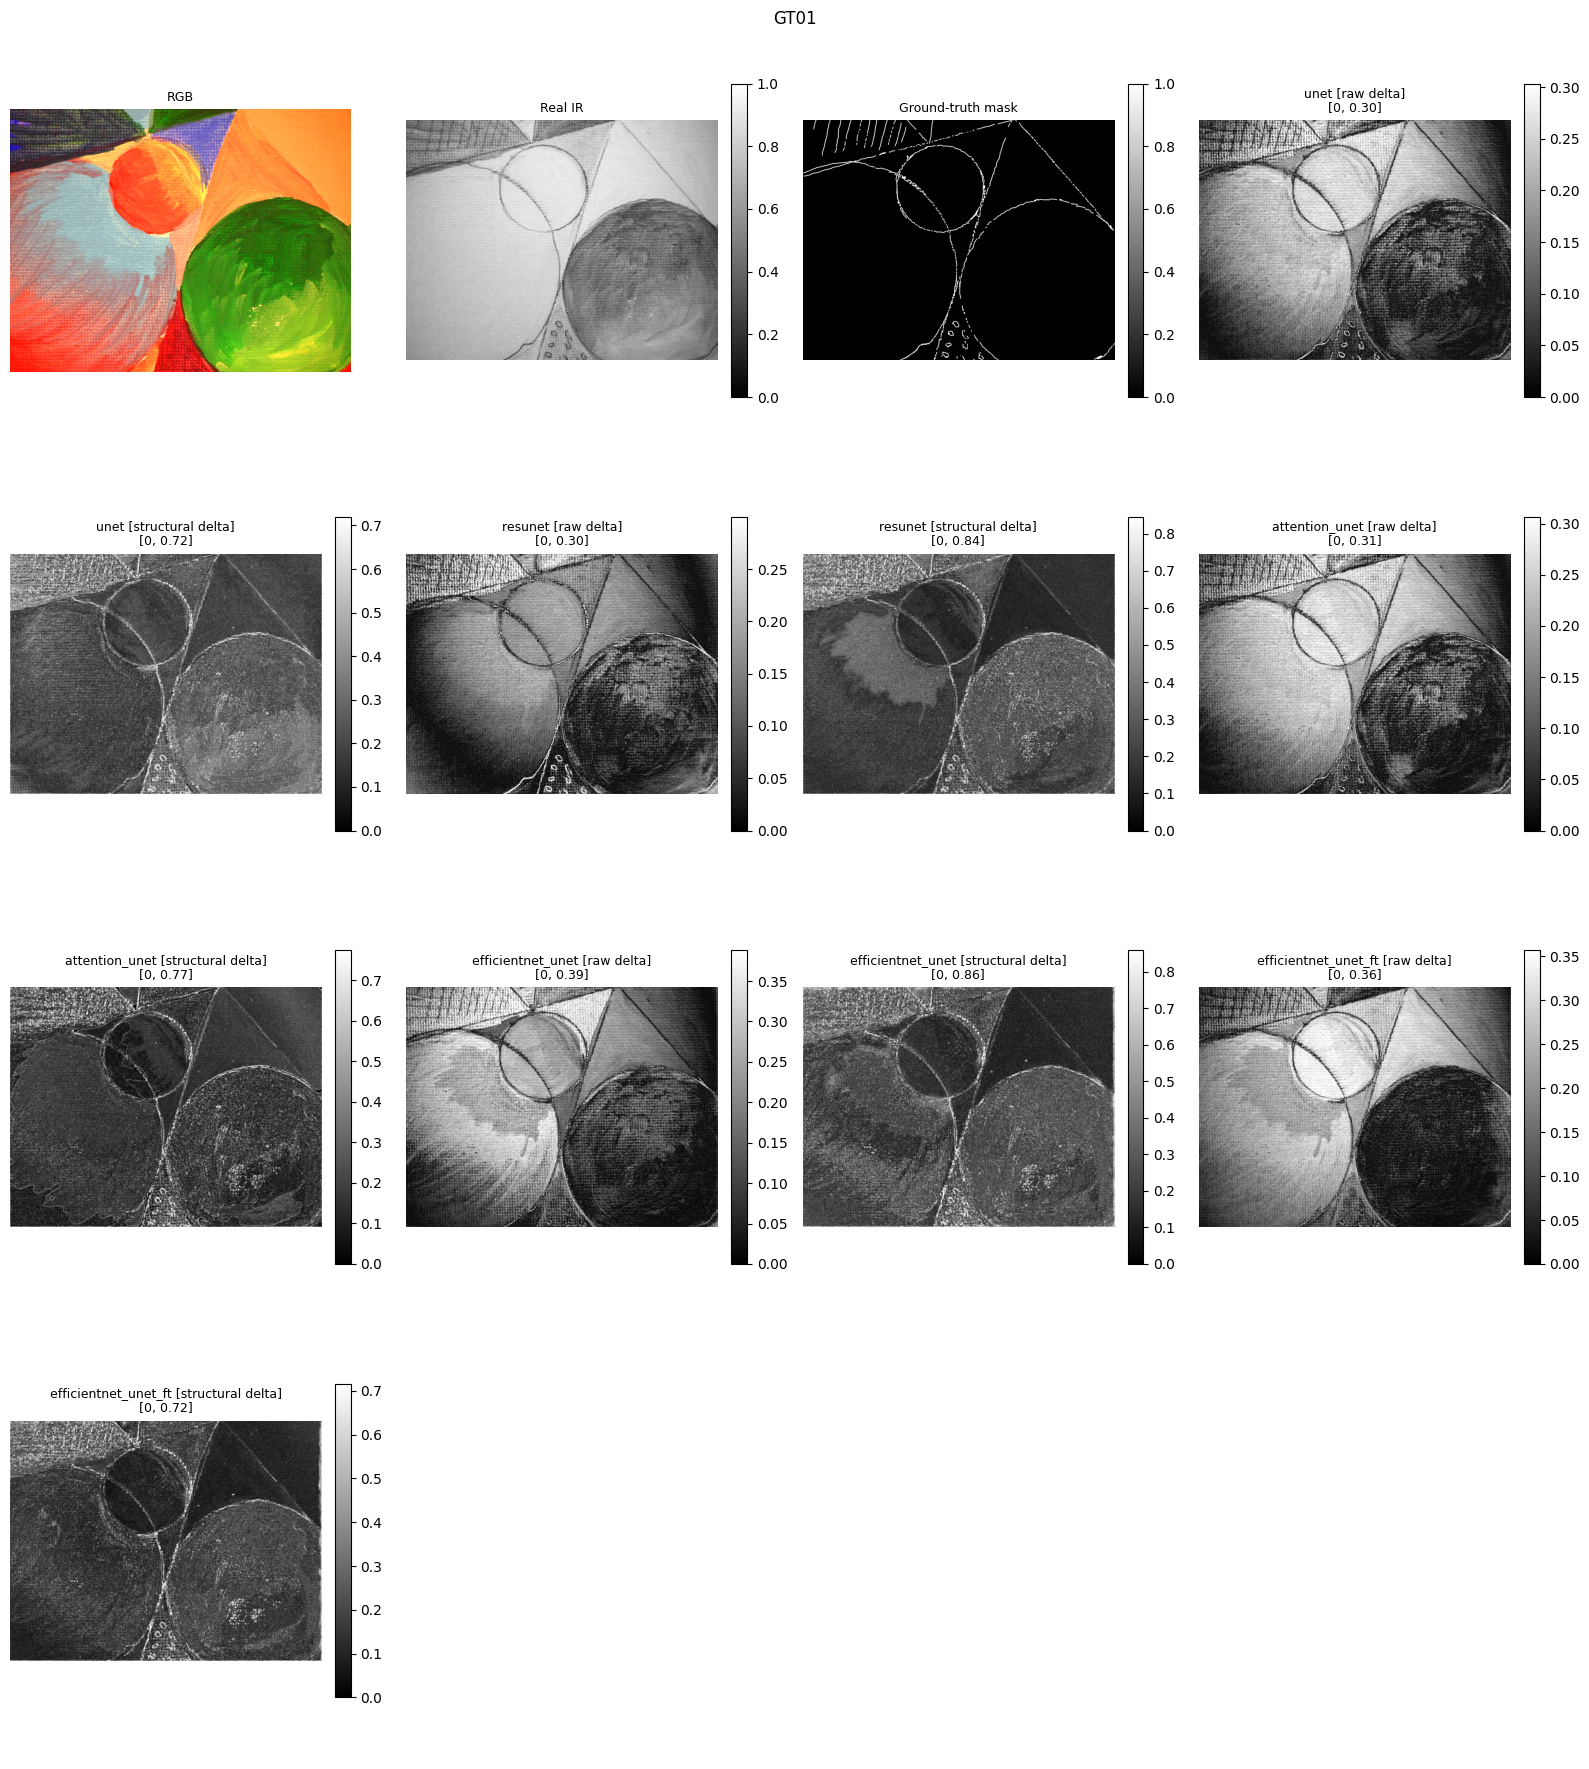

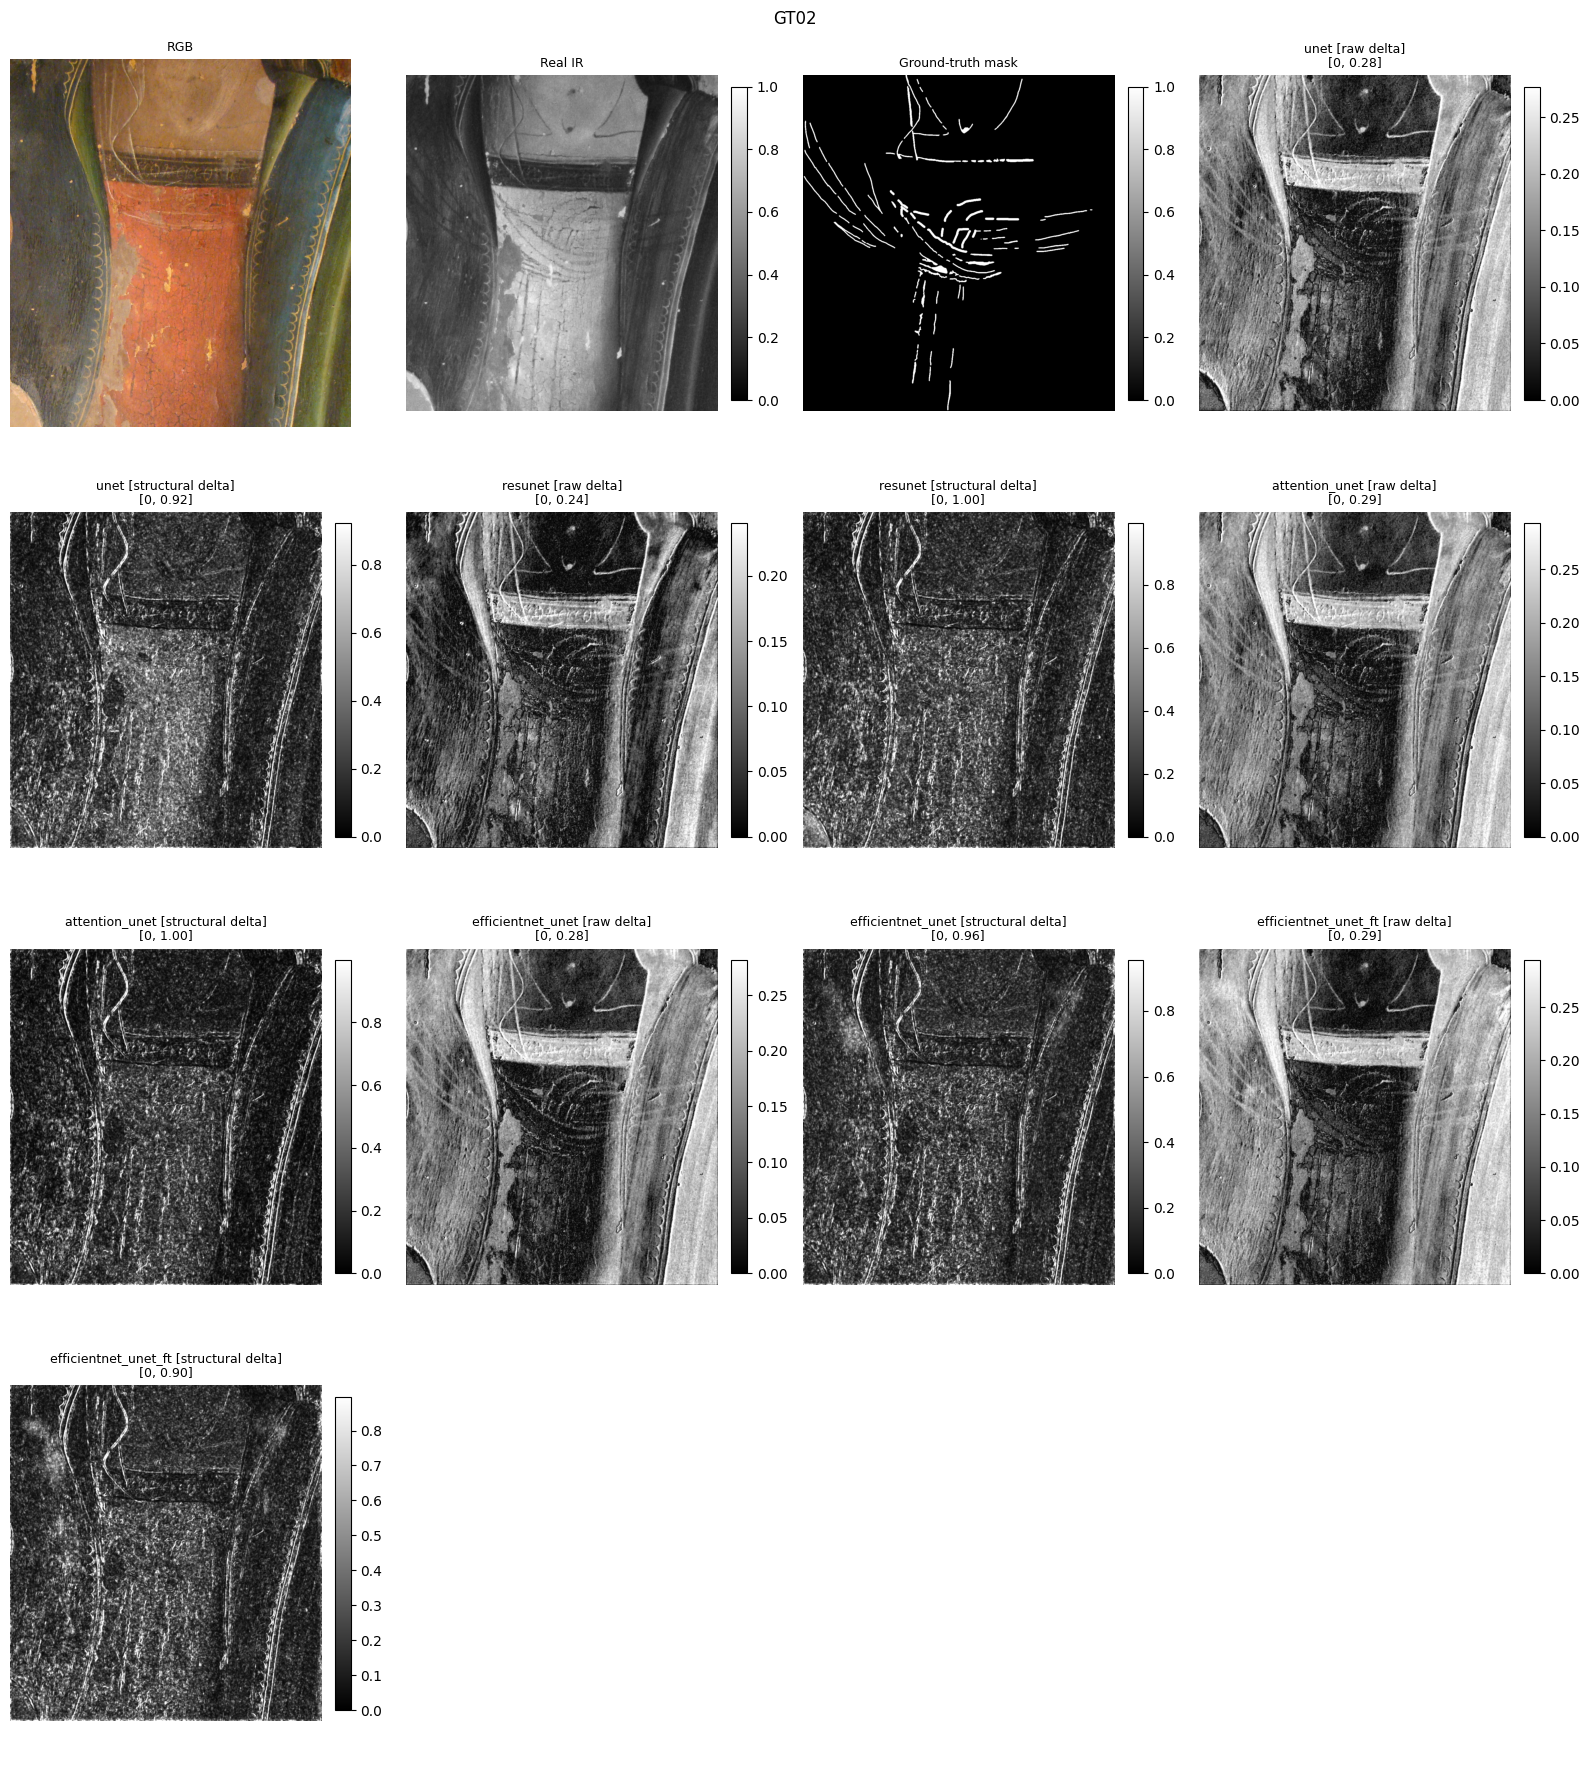

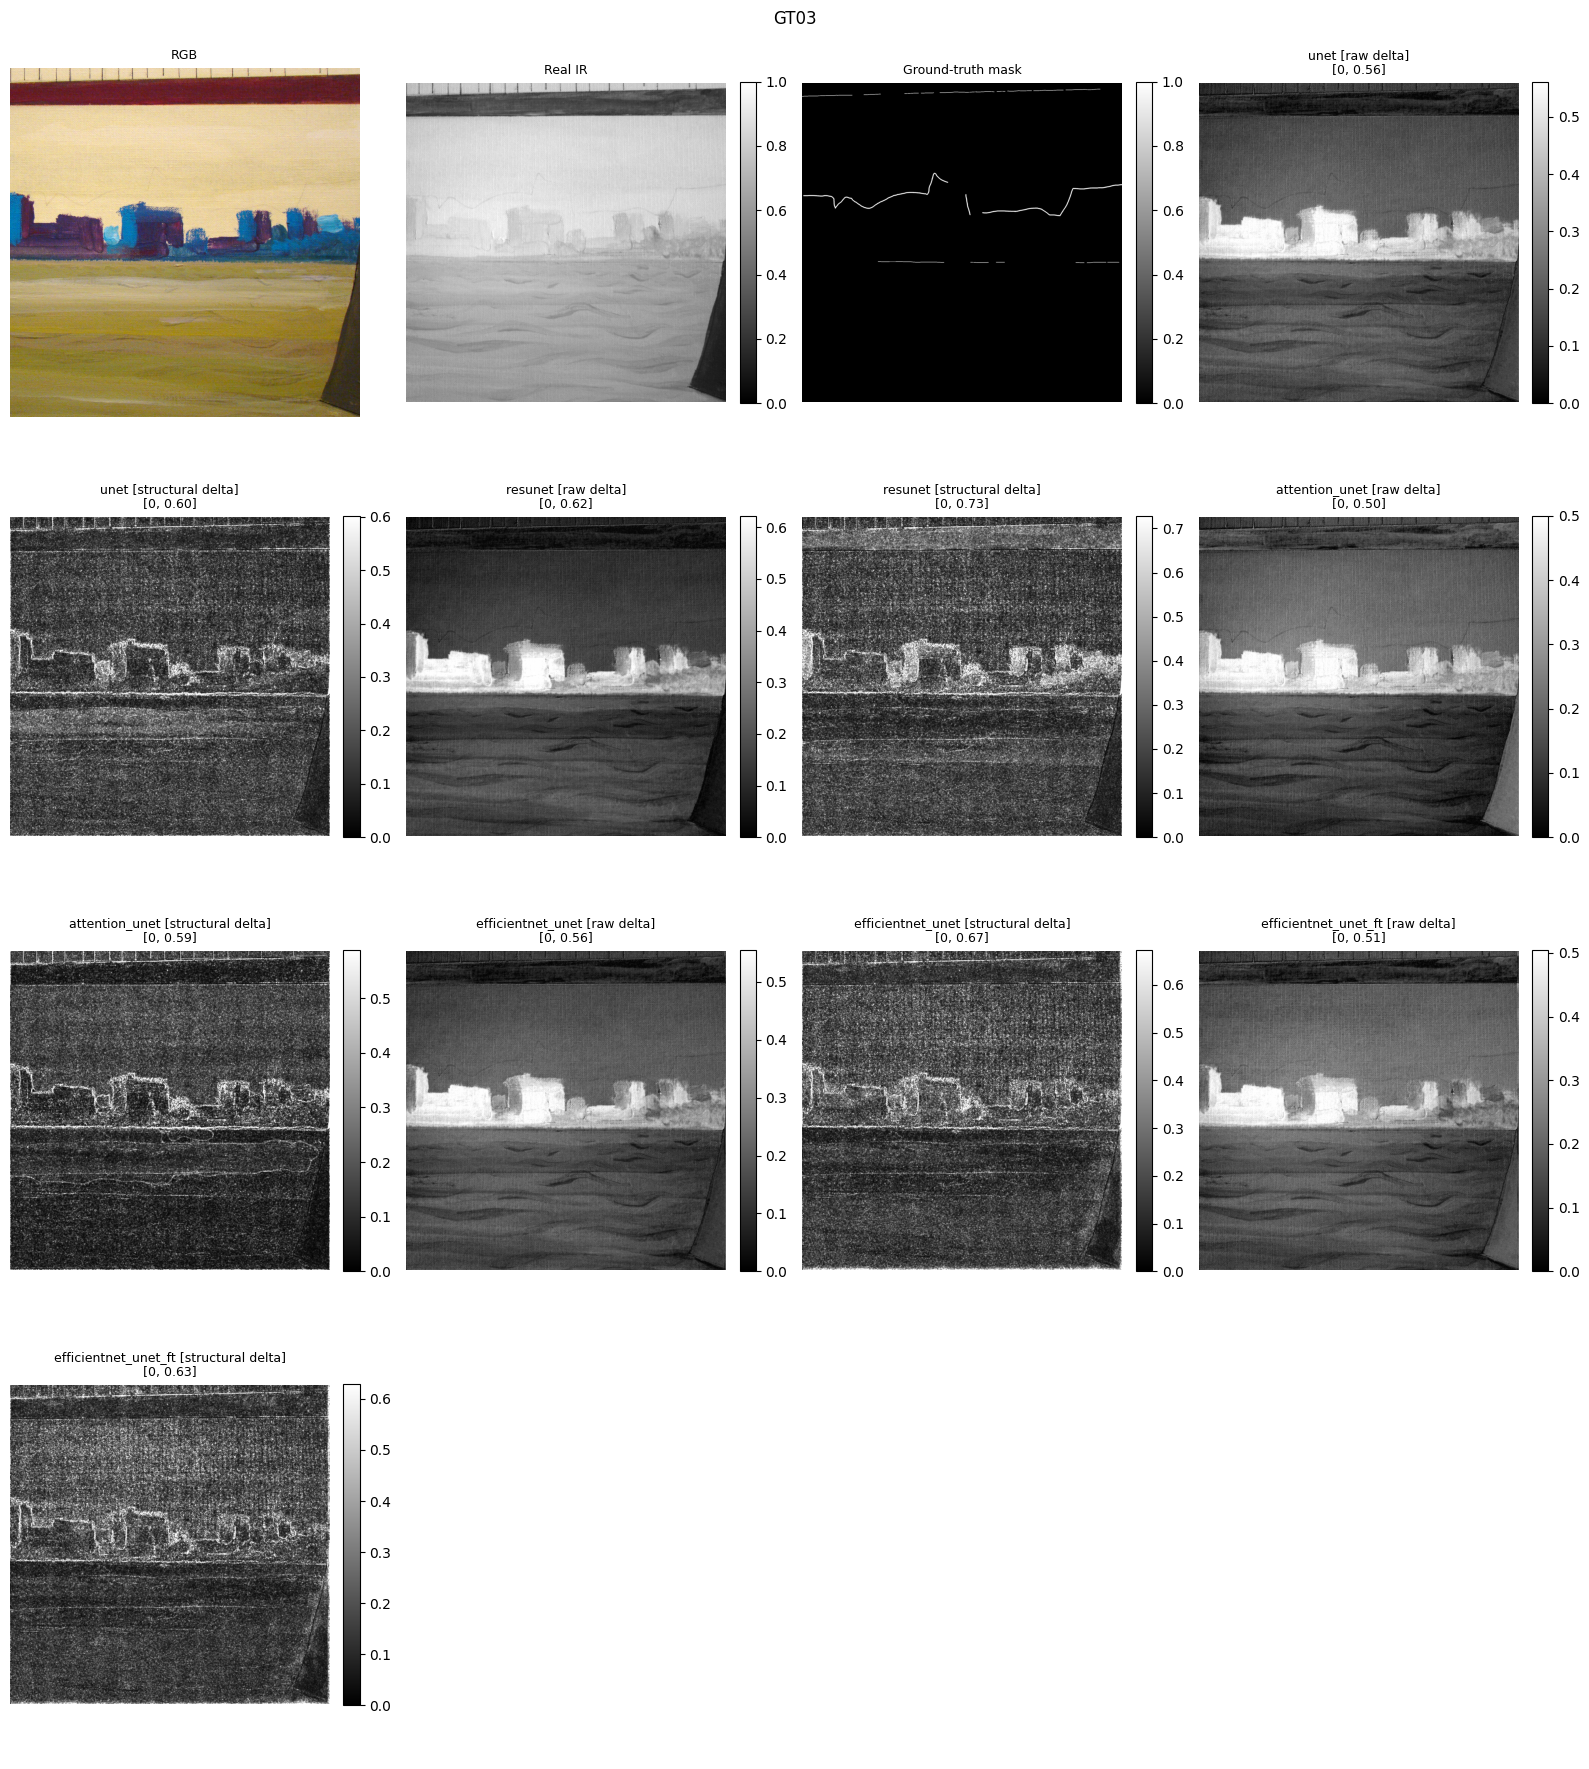

In [6]:
for rgb_path, ir_path in eval_pairs:
    rgb, ir = load_pair(rgb_path, ir_path)
    mask = load_mask(rgb_path.stem)
    signals = signals_for(rgb, ir)
    plot_gt_signal_gallery(rgb, ir, mask, signals, title=rgb_path.stem)
    plt.show()

## 4. Detection ranking

`auroc` is prevalence-independent and is the primary ranking; `std` across the 3 ground-truth images is the honest error bar and is wide with so few masks — see the per-image breakdown below before trusting the aggregate.


In [7]:
auroc_rows: dict[str, list[float]] = {}
ap_rows: dict[str, list[float]] = {}
coherence_rows: dict[str, list[float]] = {}

for rgb_path, ir_path in eval_pairs:
    rgb, ir = load_pair(rgb_path, ir_path)
    mask = load_mask(rgb_path.stem)
    signals = signals_for(rgb, ir)

    for name, result in rank_signals(signals, mask).items():
        auroc_rows.setdefault(name, []).append(result.auroc)
        ap_rows.setdefault(name, []).append(result.average_precision)
    for name, signal in signals.items():
        coherence_rows.setdefault(name, []).append(stroke_coherence(signal).coherence)

    print(f"{rgb_path.stem}: {len(signals)} signals scored")


def summarise(rows: dict[str, list[float]]) -> dict[str, tuple[float, float]]:
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in rows.items()}


auroc_mean = summarise(auroc_rows)
ranking = sorted(auroc_mean, key=lambda n: auroc_mean[n][0], reverse=True)

col_w = 40
print("\n" + "signal".ljust(col_w) + "auroc".ljust(18) + "avg_prec")
print("-" * (col_w + 30))
for name in ranking:
    a, a_sd = auroc_mean[name]
    p = float(np.mean(ap_rows[name]))
    print(f"{name.ljust(col_w)}{a:.4f} ± {a_sd:.3f}   {p:.4f}")

GT01: 10 signals scored
GT02: 10 signals scored
GT03: 10 signals scored

signal                                  auroc             avg_prec
----------------------------------------------------------------------
unet [structural delta]                 0.7073 ± 0.077   0.0676
attention_unet [structural delta]       0.7007 ± 0.042   0.0581
efficientnet_unet_ft [structural delta] 0.6970 ± 0.059   0.0580
efficientnet_unet [structural delta]    0.6856 ± 0.050   0.0562
resunet [structural delta]              0.6810 ± 0.073   0.0530
resunet [raw delta]                     0.5520 ± 0.044   0.0579
attention_unet [raw delta]              0.4993 ± 0.081   0.0226
efficientnet_unet [raw delta]           0.4810 ± 0.070   0.0162
unet [raw delta]                        0.4726 ± 0.031   0.0244
efficientnet_unet_ft [raw delta]        0.4613 ± 0.109   0.0149


### Per-image breakdown

The mean/std above collapses over the 3 ground-truth images — with `n = 3` that std can hide a signal being carried by one favorable image. Check this before treating the aggregate ranking as a conclusion (this is exactly what `063_bis` caught and resolved for the cross-family comparison).


In [8]:
gt_stems = [p.stem for p, _ in eval_pairs]
header_cols = "".join(stem.rjust(10) for stem in gt_stems)
print("signal".ljust(col_w) + header_cols)
print("-" * (col_w + 10 * len(gt_stems)))
for name in ranking:
    row = "".join(f"{v:.3f}".rjust(10) for v in auroc_rows[name])
    print(f"{name.ljust(col_w)}{row}")

signal                                        GT01      GT02      GT03
----------------------------------------------------------------------
unet [structural delta]                      0.815     0.662     0.645
attention_unet [structural delta]            0.745     0.644     0.713
efficientnet_unet_ft [structural delta]      0.762     0.620     0.708
efficientnet_unet [structural delta]         0.745     0.623     0.690
resunet [structural delta]                   0.784     0.628     0.632
resunet [raw delta]                          0.612     0.536     0.508
attention_unet [raw delta]                   0.423     0.463     0.612
efficientnet_unet [raw delta]                0.388     0.497     0.558
unet [raw delta]                             0.442     0.461     0.515
efficientnet_unet_ft [raw delta]             0.357     0.416     0.611


## 5. Stroke coherence — the reference-free corroboration

How much of each signal is oriented, line-like structure rather than isotropic noise (`scripts.stroke_stats`) — needs no mask, so it is a structurally independent check on the AUROC ranking above. Restricted to the same 3 ground-truth images as the rest of this notebook (not the full `data/test/` set — that broader, unsupervised sweep belongs to the 05x series). `034`/`063_bis` found Spearman(auroc, coherence) up to 0.76 when both axes were computed on the same real-mask images.


In [9]:
coherence_mean = summarise(coherence_rows)
by_coherence = sorted(coherence_mean, key=lambda n: coherence_mean[n][0], reverse=True)

print("signal".ljust(col_w) + "coherence (mean ± std over images)")
print("-" * (col_w + 34))
for name in by_coherence:
    c, c_sd = coherence_mean[name]
    print(f"{name.ljust(col_w)}{c:.4f} ± {c_sd:.3f}")

signal                                  coherence (mean ± std over images)
--------------------------------------------------------------------------
attention_unet [structural delta]       0.4395 ± 0.084
unet [structural delta]                 0.4081 ± 0.084
efficientnet_unet [structural delta]    0.4015 ± 0.098
resunet [structural delta]              0.3954 ± 0.089
efficientnet_unet_ft [structural delta] 0.3927 ± 0.079
attention_unet [raw delta]              0.2927 ± 0.093
efficientnet_unet [raw delta]           0.2843 ± 0.081
resunet [raw delta]                     0.2831 ± 0.079
unet [raw delta]                        0.2827 ± 0.078
efficientnet_unet_ft [raw delta]        0.2760 ± 0.079
